# IEMOCAP MER Benchmark — 4-class, LOSO 5-fold (Audio + Facial Expression)

Research-grade benchmark of the proposed cascade against three competitors on
**IEMOCAP**, under the standard 4-class / LOSO protocol. Text is not used.

## Protocol
- **Classes (4):** `neutral, happy, sad, angry`. `excited → happy`; all other
  emotions (`frustrated, fear, surprise, disgust, oth, xxx`) discarded.
- **Split:** official 5-fold **Leave-One-Session-Out** — each session is the
  test fold once; the next session (cyclic) is validation; the remaining three
  train. Final score = mean ± std over the 5 folds.
- **Metrics:** Weighted Accuracy (WA), Unweighted Accuracy (UA / UAR — main),
  Macro-F1, per-class F1, confusion matrix.

## Face selection — gender-letter heuristic
IEMOCAP `dialog/avi/DivX/*.avi` shows both actors side-by-side. The target
speaker's half-frame is chosen from the **speaker letter** in the utterance id
(`Ses01F_impro01_F000 → F → female track`): the script-leader sits on the left,
so the side is `L` when the utterance speaker letter equals the dialogue-leader
letter, else `R`. Face detection (MediaPipe BlazeFace) then runs on that half.

## Models benchmarked (the same models, all under identical conditions)
| Model | Modalities | Notes |
|---|---|---|
| Ours — BiLSTM bimodal        | audio + video (cascade) | late-fusion BiLSTM head: video BiLSTM (RAVDESS+CREMA-D pretrained) + audio branch reusing MelCNN gate's conv-stack + 256-d projection |
| Ours — BiLSTM bimodal (scr.) | audio + video (cascade) | identical architecture to *bimodal*, but **no pretrained weights** — random init for all branches |
| SCME+GF                      | audio + video | transformer + cross-attn + gated fusion |
| MM-NodeFormer                | audio + video | two-stream cross-modal transformer |
| GIA-MIC                      | audio + video | gated interactive cross-attn + modality-invariant constraints (CMD + diff + recon) |
| ResNet18+GRU                 | video         | ResNet18 frame features → BiGRU |

Every model is trained per fold with one shared trainer (same folds, loss,
optimizer schedule, early stopping) on the shared feature cache.

## Pipeline stages
1. Dataset indexing → `metadata/iemocap_4class.csv`
2/3. Video + audio preprocessing → feature cache (gender-letter faces)
4. PyTorch dataset · 5. Model interface · 6. Trainer · 7. Evaluation
8. Reproducibility · 9. Experiment tracking · 10. Final benchmark table

## 1. Configuration & reproducibility (Stages 8)

Single config dict (replaces `configs/*.yaml`; the project is notebook-based, so
Hydra/OmegaConf are intentionally not used). All paths are relative — no
hardcoded absolutes. Seeds, deterministic algorithms and the git hash are fixed
and logged for reproducibility.

In [42]:
import os, re, json, gc, time, math, pickle, random, warnings, subprocess, platform
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

# --- reproducibility (Stage 8) -----------------------------------------
SEED = 42
def seed_everything(s=SEED):
    os.environ["PYTHONHASHSEED"] = str(s)
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
seed_everything()

device = torch.device("cuda" if torch.cuda.is_available()
                       else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Device:", device)

# --- paths (run from notebooks/ or repo root — both work) --------------
ROOT = Path.cwd()
if not (ROOT / "datasets").exists() and (ROOT / ".." / "datasets").exists():
    ROOT = (ROOT / "..").resolve()
IEMOCAP_ROOT   = ROOT / "datasets" / "IEMOCAP_full_release"


FEAT_CACHE     = ROOT / "datasets" / "iemocap_features_cache_v4"
AUDIO_CKPT_DIR = ROOT / "trained_models" / "audio_neutral_3_augmentation"
VIDEO_CKPT_DIR = ROOT / "trained_models" / "video_emotion_3_augmentation"
FACE_DETECTOR  = ROOT / "raw_models" / "blaze_face_short_range.tflite"
META_DIR    = ROOT / "metadata"
RESULTS_DIR = ROOT / "results"
OUT_DIR     = ROOT / "trained_models" / "iemocap_benchmark_4class"
CKPT_DIR    = OUT_DIR / "checkpoints"
LOG_DIR     = OUT_DIR / "logs"
for d in (META_DIR, RESULTS_DIR, OUT_DIR, CKPT_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- task: 4-class IEMOCAP ---------------------------------------------
LABELS_4 = ["neutral", "happy", "sad", "angry"]
RAW2IDX  = {"neu": 0, "hap": 1, "exc": 1, "sad": 2, "ang": 3}   # exc -> hap
N_CLS    = len(LABELS_4)

# --- feature dimensions (precomputed cache) ----------------------------
FEAT_EFF, FEAT_RES, FEAT_W2V = 1280, 512, 768
N_FRAMES, N_MELS, MEL_LEN    = 16, 64, 128

# --- audio-gate log-mel normalization (from pretrained MelCNN meta) ----
_amETA   = json.load(open(AUDIO_CKPT_DIR / "meta.json"))
SR, HOP  = _amETA["SR"], _amETA["HOP"]
MEL_MEAN, MEL_STD = _amETA["mel_mean"], _amETA["mel_std"]

# --- LOSO: each session test once; next session (cyclic) = validation --
SESSIONS = [f"Session{i}" for i in range(1, 6)]
LOSO_VAL_FOR_TEST = {s: SESSIONS[(i + 1) % 5] for i, s in enumerate(SESSIONS)}

# --- training config (was configs/model_x.yaml in the spec) ------------
TRAIN_CFG = dict(
    epochs=40, patience=8, batch_size=64,
    lr=1e-3,           # competitors trained from scratch
    lr_finetune=3e-4,  # our pretrained-initialised heads
    weight_decay=1e-4, label_smoothing=0.1, grad_clip=1.0,
    accum_steps=1,     # gradient accumulation (Stage 6)
    num_workers=0,     # macOS/MPS: 0 is safest
    augment=False, aug_noise=0.05,   # optional train-only feature-space aug
)
QUICK_TEST = None  # fast 2-epoch smoke run
if QUICK_TEST:
    TRAIN_CFG["epochs"], TRAIN_CFG["patience"] = 2, 2

EPOCHS      = TRAIN_CFG["epochs"];      PATIENCE    = TRAIN_CFG["patience"]
BS          = TRAIN_CFG["batch_size"];  WD          = TRAIN_CFG["weight_decay"]
LR_SCRATCH  = TRAIN_CFG["lr"];          LR_FINETUNE = TRAIN_CFG["lr_finetune"]
LABEL_SMOOTH= TRAIN_CFG["label_smoothing"]; GRAD_CLIP = TRAIN_CFG["grad_clip"]
NUM_WORKERS = TRAIN_CFG["num_workers"]; ACCUM       = TRAIN_CFG["accum_steps"]

# Two-stage transfer for pretrained-init cascade heads (e.g. MelCNN->BiLSTM):
# stage 1 — backbone (BiLSTM/GRU) frozen, only classifier head is trained;
# stage 2 — backbone unfrozen, differential LR (low for backbone, high for head).
FREEZE_EPOCHS = 5      # head converges fast at lr=1e-3; rest is for stage 2
LR_BACKBONE   = 1e-4   # stage-2 backbone -- 10x smaller than head, gentle adapt
LR_HEAD       = 1e-3   # stage-1 head lr -- fresh Linear(64,N_CLS) needs full lr
LR_HEAD_FT    = 3e-4   # stage-2 head lr -- 3x lower than stage 1, still real lr
# Smoothing for val UA used in best-state selection and early stop:
#   ema = EMA_ALPHA * ema + (1 - EMA_ALPHA) * raw_val_ua
# Larger alpha = more smoothing (lags more). 0.5 keeps best-checkpoint robust
# to epoch-to-epoch noise without lagging the trend.
EMA_ALPHA     = 0.5

# Per-fold IEMOCAP fine-tuning of the audio gate (Phase 1):
# the pretrained MelCNN (RAVDESS+CREMA-D) over-fires 'neutral' on IEMOCAP's
# improvised dialogue. We fine-tune a per-fold copy initialised from the
# pretrained checkpoint on the LOSO training split (binary: neutral vs
# non-neutral), then use SOFT cascade at eval -- gate's log-prob is added
# as a prior to head logits (Bayesian product in log-space, lambda-scaled).
GATE_FT_EPOCHS  = 20
GATE_FT_LR      = 1e-4
GATE_FT_PAT     = 5
SOFT_LAM        = 1.0   # gate-prior weight; 0 = ignore gate, 1 = Bayesian product

def git_hash():
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=str(ROOT),
                                       stderr=subprocess.DEVNULL).decode().strip()
    except Exception:
        return "unknown"

def slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

print("git", git_hash()[:10], "| QUICK_TEST", QUICK_TEST, "| epochs", EPOCHS)
print("config:", TRAIN_CFG)

Device: mps
git 95bc39e585 | QUICK_TEST None | epochs 40
config: {'epochs': 40, 'patience': 8, 'batch_size': 64, 'lr': 0.001, 'lr_finetune': 0.0003, 'weight_decay': 0.0001, 'label_smoothing': 0.1, 'grad_clip': 1.0, 'accum_steps': 1, 'num_workers': 0, 'augment': False, 'aug_noise': 0.05}


## 2. Stage 1 — Dataset indexing

Traverse all 5 IEMOCAP sessions, parse `dialog/EmoEvaluation/*.txt` (emotion +
utterance id + timestamps) and `dialog/transcriptions/*.txt` (text). Keep the 4
benchmark classes (`exc → hap`), collect wav / video paths and speaker id, and
write `metadata/iemocap_4class.csv`.

In [43]:
EMO_LINE_RE = re.compile(r"^\[\s*([\d.]+)\s*-\s*([\d.]+)\s*\]\s+(\S+)\s+(\w+)\s+\[")
TRANS_RE    = re.compile(r"^(\S+)\s+\[[^\]]*\]\s*:\s*(.*)$")

def parse_emoeval(path, session):
    rows = []
    for line in open(path, encoding="utf-8", errors="ignore"):
        m = EMO_LINE_RE.match(line)
        if m:
            start, end, utt, emo = m.groups()
            rows.append(dict(session=session, utt_id=utt, start=float(start),
                             end=float(end), emotion_raw=emo))
    return rows

def parse_transcripts(path):
    d = {}
    for line in open(path, encoding="utf-8", errors="ignore"):
        m = TRANS_RE.match(line.strip())
        if m:
            d[m.group(1)] = m.group(2).strip()
    return d

records, transcripts = [], {}
for s in range(1, 6):
    sess = f"Session{s}"
    emo_dir = IEMOCAP_ROOT / sess / "dialog" / "EmoEvaluation"
    trn_dir = IEMOCAP_ROOT / sess / "dialog" / "transcriptions"
    for txt in sorted(emo_dir.glob("*.txt")):
        if not txt.name.startswith("."):
            records.extend(parse_emoeval(txt, sess))
    for txt in sorted(trn_dir.glob("*.txt")):
        if not txt.name.startswith("."):
            transcripts.update(parse_transcripts(txt))

meta = (pd.DataFrame.from_records(records)
          .drop_duplicates("utt_id").reset_index(drop=True))
print(f"raw utterances from EmoEvaluation: {len(meta)}")
print("emotion counts (pre-filter):", meta.emotion_raw.value_counts().to_dict())

# --- keep the 4 benchmark classes (exc -> hap) -------------------------
meta = meta[meta.emotion_raw.isin(RAW2IDX)].reset_index(drop=True)
meta["label"]   = meta.emotion_raw.map(RAW2IDX)
meta["emotion"] = meta.label.map(dict(enumerate(LABELS_4)))
meta["dialog"]  = meta.utt_id.str.rsplit("_", n=1).str[0]
# speaker id: session + utterance-speaker gender letter (Ses01F_..._F000 -> Session1_F)
meta["speaker"] = meta.apply(
    lambda r: f"{r.session}_{r.utt_id.split('_')[-1][0]}", axis=1)
meta["wav_path"] = meta.apply(
    lambda r: str(IEMOCAP_ROOT / r.session / "sentences" / "wav"
                  / r.dialog / f"{r.utt_id}.wav"), axis=1)
meta["video_path"] = meta.apply(
    lambda r: str(IEMOCAP_ROOT / r.session / "dialog" / "avi" / "DivX"
                  / f"{r.dialog}.avi"), axis=1)
meta["transcript"] = meta.utt_id.map(transcripts).fillna("")

csv_cols = ["utt_id", "session", "speaker", "label", "emotion",
            "start", "end", "wav_path", "video_path", "transcript"]
meta[csv_cols].to_csv(META_DIR / "iemocap_4class.csv", index=False)
print(f"\n4-class utterances: {len(meta)}  ->  {META_DIR / 'iemocap_4class.csv'}")
print(meta.groupby(["session", "emotion"]).size().unstack(fill_value=0))

raw utterances from EmoEvaluation: 10039
emotion counts (pre-filter): {'xxx': 2507, 'fru': 1849, 'neu': 1708, 'ang': 1103, 'sad': 1084, 'exc': 1041, 'hap': 595, 'sur': 107, 'fea': 40, 'oth': 3, 'dis': 2}

4-class utterances: 5531  ->  /Users/kaparya/Desktop/Diploma/metadata/iemocap_4class.csv
emotion   angry  happy  neutral  sad
session                             
Session1    229    278      384  194
Session2    137    327      362  197
Session3    240    286      320  305
Session4    327    303      258  143
Session5    170    442      384  245


## 3. Stage 2 & 3 — Video / audio preprocessing → feature cache

Per-utterance features are cached at `datasets/iemocap_features_cache/{utt}.pt`
(`video_eff` 16×1280 EmotiEffNet · `video_res` 16×512 ResNet18 · `audio_w2v`
16×768 Wav2Vec2 · `audio_mel` 64×128 log-mel).

**Video.** 16 frames uniformly sampled per utterance; the target speaker's
half-frame is picked by the **gender-letter heuristic** (`speaker_side`); face
detected with MediaPipe BlazeFace (centre-crop fallback on a miss); 224×224 crop
→ EmotiEffNet + ResNet18 features. **Audio.** Resampled to 16 kHz, log-mel
normalized with the pretrained MelCNN stats; Wav2Vec2 embeddings pooled to 16
chunks.

The cell below is **resumable**: it extracts only utterances missing from the
cache and otherwise costs nothing. Heavy extractor models load only if needed.

In [44]:
def cache_file(utt): return FEAT_CACHE / f"{utt}.pt"

def speaker_side(utt_id):
    """Gender-letter heuristic: leader letter vs utterance-speaker letter."""
    leader = utt_id.split("_")[0][-1]      # dialogue-leader gender (Ses01F -> F)
    spk    = utt_id.split("_")[-1][0]      # utterance speaker gender (F000 -> F)
    return "L" if spk == leader else "R"

def crop_half(frame, lr):
    mid = frame.shape[1] // 2
    return frame[:, :mid] if lr == "L" else frame[:, mid:]

FEAT_CACHE.mkdir(parents=True, exist_ok=True)
missing = [u for u in meta.utt_id if not cache_file(u).exists()]
print(f"cached: {len(meta) - len(missing)} / {len(meta)}   missing: {len(missing)}")

# v4 is prebuilt by full_pipeline_iemocap_augmented.ipynb. If files are missing
# here, rebuild via THAT notebook -- the build path below uses the buggy v3-style
# gender-letter side heuristic + centre-crop fallback and is kept only for
# documentation. Refuse to silently regenerate bad data.
if missing and "v4" in FEAT_CACHE.name:
    raise RuntimeError(
        f"{len(missing)} v4 cache files missing. v4 must be rebuilt via "
        f"full_pipeline_iemocap_augmented.ipynb (correct face + mouth-motion). "
        f"Do NOT regenerate v4 from this notebook -- its build path uses the "
        f"v3-style gender-letter side heuristic which is ~50% wrong.")

if missing:
    print("Extracting missing utterances (one-time, slow)...")
    import cv2, librosa
    import torchvision.models as tv_models
    import torchvision.transforms as T
    import mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision
    from emotiefflib.facial_analysis import EmotiEffLibRecognizer
    from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

    eff = EmotiEffLibRecognizer(engine="torch", model_name="enet_b0_8_best_vgaf",
                                device=str(device)).model.to(device).eval()
    resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
    resnet.fc = nn.Identity(); resnet = resnet.to(device).eval()
    w2v_proc = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")
    w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device).eval()
    for m in (eff, resnet, w2v):
        for p in m.parameters(): p.requires_grad_(False)
    det = mp_vision.FaceDetector.create_from_options(mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(FACE_DETECTOR)),
        min_detection_confidence=0.5))
    tf = T.Compose([T.ToTensor(),
                    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    def detect_crop(frame, size=224):
        img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        res = det.detect(img)
        if res.detections:
            bb = res.detections[0].bounding_box
            h, w = frame.shape[:2]
            px, py = int(bb.width * 0.1), int(bb.height * 0.1)
            x1, y1 = max(0, bb.origin_x - px), max(0, bb.origin_y - py)
            x2 = min(w, bb.origin_x + bb.width + px)
            y2 = min(h, bb.origin_y + bb.height + py)
            if x2 > x1 and y2 > y1:
                return cv2.resize(frame[y1:y2, x1:x2], (size, size))
        h, w = frame.shape[:2]; s = min(h, w)              # fallback: centre crop
        return cv2.resize(frame[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s], (size, size))

    def extract_frames(avi, start, end, n=N_FRAMES):
        cap = cv2.VideoCapture(avi)
        if not cap.isOpened(): return []
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        s = max(0, int(start * fps)); e = min(total - 1, int(end * fps))
        if e <= s: e = min(total - 1, s + 1)
        frames = []
        for i in np.linspace(s, e, n, dtype=int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ok, fr = cap.read()
            if ok: frames.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
        cap.release()
        return frames

    @torch.no_grad()
    def video_feats(avi, start, end, lr):
        fr = extract_frames(avi, start, end)
        if not fr:
            crops = [np.zeros((224, 224, 3), np.uint8)] * N_FRAMES
        else:
            while len(fr) < N_FRAMES: fr.append(fr[-1])
            crops = [detect_crop(crop_half(f, lr)) for f in fr[:N_FRAMES]]
        b = torch.stack([tf(c) for c in crops]).to(device)
        return (eff(b).cpu().float(), resnet(b).cpu().float())

    def logmel(y):
        mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
        lm = librosa.power_to_db(mel, ref=np.max)
        lm = (np.pad(lm, ((0, 0), (0, MEL_LEN - lm.shape[1]))) if lm.shape[1] < MEL_LEN
              else lm[:, :MEL_LEN])
        return torch.tensor((lm - MEL_MEAN) / (MEL_STD + 1e-8), dtype=torch.float32)

    @torch.no_grad()
    def w2v_feats(y, n=N_FRAMES):
        inp = w2v_proc(y, sampling_rate=SR, return_tensors="pt").input_values.to(device)
        out = w2v(inp).last_hidden_state[0].cpu().numpy()
        if out.shape[0] >= n:
            idx = np.linspace(0, out.shape[0], n + 1, dtype=int)
            out = np.stack([out[idx[i]:idx[i+1]].mean(0) for i in range(n)])
        else:
            out = np.pad(out, ((0, n - out.shape[0]), (0, 0)))
        return torch.tensor(out, dtype=torch.float32)

    mrows = meta[meta.utt_id.isin(set(missing))]
    for r in tqdm(list(mrows.itertuples()), desc="extract"):
        try:
            y, _ = librosa.load(r.wav_path, sr=SR, mono=True)
            ve, vr = video_feats(r.video_path, r.start, r.end, speaker_side(r.utt_id))
            torch.save(dict(video_eff=ve, video_res=vr,
                            audio_w2v=w2v_feats(y), audio_mel=logmel(y),
                            label=int(r.label), utt_id=r.utt_id), cache_file(r.utt_id))
        except Exception as e:
            print("FAIL", r.utt_id, e)
    print("extraction done.")
else:
    print("Feature cache complete — no extraction needed.")

cached: 5531 / 5531   missing: 0
Feature cache complete — no extraction needed.


Keep only utterances with a cache file, then **preload all features into RAM**
(~1 GB) so per-fold training never touches disk.

In [45]:
meta = meta[meta.utt_id.apply(lambda u: cache_file(u).exists())].reset_index(drop=True)
print(f"utterances with features: {len(meta)}")

if QUICK_TEST:
    meta = (pd.concat([d.sample(min(len(d), 120), random_state=SEED)
                       for _, d in meta.groupby("session")])
              .reset_index(drop=True))
    print(f"QUICK_TEST subsample -> {len(meta)}")

print("Preloading feature cache into RAM...")
FEATS, LABELS = {}, {}
for r in tqdm(list(meta.itertuples()), desc="preload"):
    d = torch.load(cache_file(r.utt_id), weights_only=False)
    FEATS[r.utt_id] = dict(audio_mel=d["audio_mel"].float(),
                           audio_w2v=d["audio_w2v"].float(),
                           video_eff=d["video_eff"].float(),
                           video_res=d["video_res"].float())
    LABELS[r.utt_id] = int(r.label)          # 4-class label from metadata
print(meta.groupby(["session", "emotion"]).size().unstack(fill_value=0))

utterances with features: 5531
Preloading feature cache into RAM...


preload:   0%|          | 0/5531 [00:00<?, ?it/s]

emotion   angry  happy  neutral  sad
session                             
Session1    229    278      384  194
Session2    137    327      362  197
Session3    240    286      320  305
Session4    327    303      258  143
Session5    170    442      384  245


## 4. Stage 4 — PyTorch dataset

`IEMOCAPBenchDS` returns `(features_dict, label, utt_id)` where `features_dict`
holds every modality stream; each model picks the streams it needs. Optional
train-only augmentation is feature-space Gaussian noise — image-space
crop/flip/jitter cannot apply to frozen pre-extracted embeddings.

In [46]:
class IEMOCAPBenchDS(Dataset):
    """Returns ({audio_mel,audio_w2v,video_eff,video_res}, label, utt_id)."""
    def __init__(self, df, train=False):
        self.utts  = df.utt_id.tolist()
        self.train = train and TRAIN_CFG["augment"]
    def __len__(self):
        return len(self.utts)
    def __getitem__(self, i):
        u = self.utts[i]; f = FEATS[u]
        am, aw, ve, vr = (f["audio_mel"], f["audio_w2v"],
                          f["video_eff"], f["video_res"])
        if self.train:                                   # train-only feature aug
            s = TRAIN_CFG["aug_noise"]
            ve = ve + torch.randn_like(ve) * ve.std() * s
            vr = vr + torch.randn_like(vr) * vr.std() * s
            aw = aw + torch.randn_like(aw) * aw.std() * s
        batch = dict(audio_mel=am.unsqueeze(0), audio_w2v=aw,
                     video_eff=ve, video_res=vr)
        return batch, torch.tensor(LABELS[u], dtype=torch.long), u

def make_loader(df, train, bs=BS):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(IEMOCAPBenchDS(df, train=train), batch_size=bs,
                      shuffle=train, drop_last=train,
                      num_workers=NUM_WORKERS, generator=g)

def to_device(batch):
    return {k: v.to(device) for k, v in batch.items()}

print("Dataset ready.")

Dataset ready.


## 5. Stage 5 — Models & unified interface

`BaseMERModel` is the shared interface (`forward / training_step /
validation_step / predict`). The audio gate (`MelCNN`), video heads
(`BiLSTM/BiGRU`) and competitors (`SCME+GF`, `MM-NodeFormer`, `ResNet18+GRU`)
are the proven architectures from the existing IEMOCAP notebooks.

In [47]:
class BaseMERModel(nn.Module):
    """Unified interface — every benchmark model subclasses this."""
    MODALITIES = ()
    def forward(self, batch):
        raise NotImplementedError
    def training_step(self, batch, y, criterion):
        logits = self(batch)
        return criterion(logits, y), logits
    @torch.no_grad()
    def validation_step(self, batch, y, criterion):
        logits = self(batch)
        return criterion(logits, y), logits
    @torch.no_grad()
    def predict(self, batch):
        return self(batch).argmax(1)


class MelCNN(nn.Module):
    """Binary neutral / non-neutral audio gate (log-mel input)."""
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * (n_mels // 8) * (max_len // 8), 256),
            nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, 2))
    def forward(self, x):
        return self.classifier(self.features(x))


class BiLSTMBimodal(nn.Module):
    """Late-fusion bimodal head. Video branch = pretrained BiLSTM over EmotiEffNet
    features. Audio branch reuses the MelCNN gate's backbone (conv stack + 256-d
    projection), dropping its binary head -- this keeps the bimodal cascade in
    the ~30 MB size class (gate weights are SHARED between the cascade gate and
    the head's audio branch) while gaining a second modality. Audio input is
    `audio_mel` (1, 64, 128), exactly what the gate already consumes."""

    # All three modules carry pretrained weights (video BiLSTM from
    # RAVDESS+CREMA-D, audio_features + audio_proj from the MelCNN gate).
    # The trainer treats them as the "backbone" param group (low LR);
    # only `classifier` is fresh-init and gets the head LR.
    pretrained_modules = ("bilstm_v", "audio_features", "audio_proj")

    def __init__(self, feat_dim_v=1280, hidden=128, n_classes=4,
                 n_mels=64, mel_len=128, audio_dim=256, dropout=0.3):
        super().__init__()
        # --- video branch (pretrained from RAVDESS+CREMA-D BiLSTM head)
        self.bilstm_v = nn.LSTM(feat_dim_v, hidden, num_layers=1, batch_first=True,
                                bidirectional=True)
        # --- audio branch (pretrained from MelCNN gate, binary head dropped)
        # mirrors MelCNN.features so we can copy state_dict directly.
        self.audio_features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        flat_dim = 64 * (n_mels // 8) * (mel_len // 8)
        # audio_proj corresponds to MelCNN.classifier[1] (Linear(8192, 256)).
        self.audio_proj = nn.Linear(flat_dim, audio_dim)
        self.audio_drop = nn.Dropout(dropout)
        # --- fusion classifier (fresh init)
        # video hidden = 2 * hidden (bi-directional concat); audio = audio_dim.
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden + audio_dim, 64), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(64, n_classes))

    def forward(self, video, audio_mel):
        _, (hv, _) = self.bilstm_v(video)              # (2, B, hidden)
        h_v = torch.cat([hv[-2], hv[-1]], dim=-1)      # (B, 2*hidden = 256)
        x = self.audio_features(audio_mel)             # (B, 64, n_mels/8, mel_len/8)
        x = x.flatten(1)                               # (B, 8192)
        h_a = self.audio_drop(F.relu(self.audio_proj(x)))   # (B, 256)
        return self.classifier(torch.cat([h_v, h_a], dim=-1))




class SCME_GF(nn.Module):
    """Simplified SCME+GF: per-stream transformer + cross-attention + gated fusion."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        enc = lambda: nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, n_heads, 256, dropout,
                                       batch_first=True, activation="gelu"), 2)
        self.enc_a, self.enc_v = enc(), enc()
        self.x_av = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.x_va = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.gate = nn.Sequential(nn.Linear(2 * d_model, d_model), nn.Sigmoid())
        self.cls  = nn.Sequential(nn.Linear(d_model, 64), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(64, n_classes))
    def forward(self, a, v):
        a = self.enc_a(self.proj_a(a)); v = self.enc_v(self.proj_v(v))
        a2, _ = self.x_av(a, v, v); v2, _ = self.x_va(v, a, a)
        a2, v2 = a2.mean(1), v2.mean(1)
        g = self.gate(torch.cat([a2, v2], dim=-1))
        return self.cls(g * a2 + (1 - g) * v2)


class CrossLayer(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.sa_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.sa_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_a = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.ca_v = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
        self.na, self.nv = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff_a = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
        self.ff_v = nn.Sequential(nn.Linear(d, d*2), nn.GELU(), nn.Linear(d*2, d))
    def forward(self, a, v):
        a = a + self.sa_a(a, a, a)[0]; v = v + self.sa_v(v, v, v)[0]
        a2 = a + self.ca_a(a, v, v)[0]; v2 = v + self.ca_v(v, a, a)[0]
        return self.na(a2 + self.ff_a(a2)), self.nv(v2 + self.ff_v(v2))


class MM_NodeFormer(nn.Module):
    """Simplified MM-NodeFormer: two-stream cross-modal transformer."""
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_layers=3, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        self.layers = nn.ModuleList([CrossLayer(d_model, n_heads, dropout)
                                     for _ in range(n_layers)])
        self.cls = nn.Sequential(nn.Linear(2 * d_model, 128), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(128, n_classes))
    def forward(self, a, v):
        a, v = self.proj_a(a), self.proj_v(v)
        for ly in self.layers:
            a, v = ly(a, v)
        return self.cls(torch.cat([a.mean(1), v.mean(1)], dim=-1))


class ResNetGRU(nn.Module):
    """ResNet18 frame features -> bidirectional GRU."""
    def __init__(self, feat_dim=FEAT_RES, hidden=128, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(feat_dim, hidden, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=dropout)
        self.cls = nn.Sequential(nn.Linear(hidden * 2, 64), nn.ReLU(),
                                 nn.Dropout(0.5), nn.Linear(64, n_classes))
    def forward(self, x):
        _, h = self.gru(x)
        return self.cls(torch.cat([h[-2], h[-1]], dim=-1))

# --- GIA-MIC -----------------------------------------------------------------
# He, Jin, Mi (2025). GIA-MIC: Multimodal Emotion Recognition with Gated
# Interactive Attention and Modality-Invariant Learning Constraints.
# arXiv:2506.00865.
def _cmd_loss(x, y, k=5):
    """Central Moment Discrepancy up to order k (Zellinger et al., ICLR 2017).
    Distribution alignment without kernels -- used as the modality-invariant
    similarity loss (pull shared_a and shared_v together)."""
    mx, my = x.mean(0), y.mean(0)
    loss = (mx - my).norm(p=2)
    sx, sy = x - mx, y - my
    for i in range(2, k + 1):
        loss = loss + (sx.pow(i).mean(0) - sy.pow(i).mean(0)).norm(p=2)
    return loss

def _diff_loss(a, b, eps=1e-6):
    """Soft orthogonality between two batches of vectors (shared vs private).
    Centred + L2-normalised, then squared Frobenius of A^T B (mean over dims)."""
    a = a - a.mean(0, keepdim=True)
    b = b - b.mean(0, keepdim=True)
    a = F.normalize(a, p=2, dim=1, eps=eps)
    b = F.normalize(b, p=2, dim=1, eps=eps)
    return (a.t() @ b).pow(2).mean()


class GIAMICHead(nn.Module):
    """Gated Interactive Attention + Modality-Invariant Constraints (GIA-MIC).

    Two-stream architecture over `audio_w2v` (T, 768) + `video_eff` (T, 1280):
      1. project both modalities to a common d_model, self-encode each;
      2. cross-modal attention each way + per-token sigmoid gates blend the
         cross-attended stream with the original (the GIA block);
      3. mean-pool over time, then split each modality into a SHARED
         (modality-invariant) and a PRIVATE (modality-specific) representation
         via separate projectors -- the shared projector is the SAME network
         for both modalities, which is what enables CMD alignment;
      4. classify on concat(shared_a, shared_v, private_a, private_v);
      5. auxiliary losses are baked into `GIAMICModel.training_step` -- CMD
         similarity pulls the shared subspaces together, soft-orthogonality
         pushes shared/private apart per modality, reconstruction prevents
         the decomposition from collapsing.
    """
    def __init__(self, d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                 n_heads=4, n_classes=N_CLS, dropout=0.3):
        super().__init__()
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_video, d_model)
        self.enc_a = nn.TransformerEncoderLayer(d_model, n_heads, 256, dropout,
                                                batch_first=True, activation="gelu")
        self.enc_v = nn.TransformerEncoderLayer(d_model, n_heads, 256, dropout,
                                                batch_first=True, activation="gelu")
        # Gated Interactive Attention: cross-attn each way + per-token gates.
        self.gia_a = nn.MultiheadAttention(d_model, n_heads, dropout=dropout,
                                           batch_first=True)
        self.gia_v = nn.MultiheadAttention(d_model, n_heads, dropout=dropout,
                                           batch_first=True)
        self.gate_a = nn.Sequential(nn.Linear(2 * d_model, d_model), nn.Sigmoid())
        self.gate_v = nn.Sequential(nn.Linear(2 * d_model, d_model), nn.Sigmoid())
        # Subspace decomposition: shared projector is parameter-shared across
        # modalities (key to CMD alignment); private projectors are separate.
        self.shared = nn.Sequential(nn.Linear(d_model, d_model),
                                    nn.LayerNorm(d_model), nn.GELU())
        self.priv_a = nn.Sequential(nn.Linear(d_model, d_model),
                                    nn.LayerNorm(d_model), nn.GELU())
        self.priv_v = nn.Sequential(nn.Linear(d_model, d_model),
                                    nn.LayerNorm(d_model), nn.GELU())
        # Reconstruction decoders (regularise the subspace decomposition).
        self.dec_a = nn.Linear(d_model, d_model)
        self.dec_v = nn.Linear(d_model, d_model)
        # Classifier on concat(shared_a, shared_v, priv_a, priv_v).
        self.cls = nn.Sequential(nn.Linear(4 * d_model, 64), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(64, n_classes))

    def forward(self, a, v, return_aux=False):
        a = self.enc_a(self.proj_a(a))                  # (B, T, d)
        v = self.enc_v(self.proj_v(v))
        a_x, _ = self.gia_a(a, v, v)                    # audio queries video
        v_x, _ = self.gia_v(v, a, a)                    # video queries audio
        g_a = self.gate_a(torch.cat([a, a_x], dim=-1))  # (B, T, d) in [0,1]
        g_v = self.gate_v(torch.cat([v, v_x], dim=-1))
        a = g_a * a_x + (1.0 - g_a) * a
        v = g_v * v_x + (1.0 - g_v) * v
        a_p = a.mean(1); v_p = v.mean(1)                # (B, d) pooled
        a_s = self.shared(a_p); v_s = self.shared(v_p)  # shared (modality-invariant)
        a_q = self.priv_a(a_p); v_q = self.priv_v(v_p)  # private (modality-specific)
        a_r = self.dec_a(a_s + a_q); v_r = self.dec_v(v_s + v_q)
        logits = self.cls(torch.cat([a_s, v_s, a_q, v_q], dim=-1))
        if return_aux:
            return logits, dict(a_s=a_s, v_s=v_s, a_q=a_q, v_q=v_q,
                                a_r=a_r, v_r=v_r, a_p=a_p, v_p=v_p)
        return logits


print("Model classes defined.")

Model classes defined.


Adapters wrap each architecture in the `BaseMERModel` interface and select their
input streams. The two pretrained-cascade heads are initialised from the
RAVDESS+CREMA-D pretrained 8-class checkpoints; the final layer is remapped 8→4
by averaging the source rows (`calm→neutral`, `surprised→happy`). A third
cascade variant (`Ours (BiLSTM, scratch)`) shares the same architecture but is
trained from random initialisation — a controlled ablation of the pretrained-init
contribution. The `MelCNN` gate is loaded pretrained and **frozen** — at
evaluation it overrides the prediction to `neutral` whenever it flags the
utterance as neutral (the cascade).

In [48]:
class SingleStreamModel(BaseMERModel):
    """Wraps a head consuming one (T, D) feature stream."""
    def __init__(self, head, key, modalities):
        super().__init__(); self.head = head; self.key = key
        self.MODALITIES = modalities
    def forward(self, batch):
        return self.head(batch[self.key])

class FusionModel(BaseMERModel):
    """Wraps a head consuming (audio_w2v, video_eff)."""
    MODALITIES = ("audio", "video")
    def __init__(self, head):
        super().__init__(); self.head = head
    def forward(self, batch):
        return self.head(batch["audio_w2v"], batch["video_eff"])

class BimodalModel(BaseMERModel):
    """Wraps a head that consumes (video_eff, audio_mel). Audio is the SAME
    log-mel tensor consumed by the cascade gate -- the bimodal head reuses
    the MelCNN backbone internally, so we don't need Wav2Vec2 at inference."""
    MODALITIES = ("audio", "video")
    def __init__(self, head):
        super().__init__(); self.head = head
    def forward(self, batch):
        return self.head(batch["video_eff"], batch["audio_mel"])

class GIAMICModel(BaseMERModel):
    """Wraps `GIAMICHead`. Adds modality-invariant constraints to the
    CE loss inside `training_step` -- the trainer itself stays unchanged
    (it just calls `model.training_step(batch, y, criterion)`).

    Inference path (forward) returns logits only, so cascade/soft-prior
    fusion, EMA early-stopping, and the inference helpers work as-is.
    """
    MODALITIES = ("audio", "video")
    # CMD on random shared projections is large (~30 at init for d=128);
    # LAM_SIM=0.1 keeps it from dominating CE during early epochs.
    LAM_SIM  = 0.1
    LAM_DIFF = 0.3
    LAM_REC  = 0.1
    def __init__(self, head):
        super().__init__(); self.head = head
    def forward(self, batch):
        return self.head(batch["audio_w2v"], batch["video_eff"])
    def training_step(self, batch, y, criterion):
        logits, aux = self.head(batch["audio_w2v"], batch["video_eff"],
                                return_aux=True)
        loss_cls  = criterion(logits, y)
        loss_sim  = _cmd_loss(aux["a_s"], aux["v_s"])
        loss_diff = (_diff_loss(aux["a_s"], aux["a_q"]) +
                     _diff_loss(aux["v_s"], aux["v_q"]))
        loss_rec  = (F.mse_loss(aux["a_r"], aux["a_p"].detach()) +
                     F.mse_loss(aux["v_r"], aux["v_p"].detach()))
        loss = (loss_cls + self.LAM_SIM * loss_sim
                + self.LAM_DIFF * loss_diff + self.LAM_REC * loss_rec)
        return loss, logits


# RAVDESS(8) -> 4-class: neutral,calm->neutral; happy,surprised->happy;
#               sad->sad; angry->angry; fearful,disgust-> none (-1)
RAVDESS_TO_IEMOCAP4 = [0, 0, 1, 2, 3, -1, -1, 1]

def remap_final_linear(old_fc, mapping, n_out):
    """Replace Linear(in,8) with Linear(in,n_out), averaging mapped source rows."""
    new_fc = nn.Linear(old_fc.in_features, n_out)
    with torch.no_grad():
        for c in range(n_out):
            idx = [i for i, m in enumerate(mapping) if m == c]
            if idx:
                new_fc.weight[c] = old_fc.weight[idx].mean(0)
                new_fc.bias[c]   = old_fc.bias[idx].mean(0)
    return new_fc

def build_ours_bilstm_bimodal():
    """Pretrained-init bimodal head. Video branch = pretrained BiLSTM
    from RAVDESS+CREMA-D. Audio branch = MelCNN gate's features +
    256-d projection (binary head dropped). Classifier = fresh init.
    Audio weights come from the GLOBAL pretrained gate; per-fold gate
    fine-tuning still happens separately for the cascade prior."""
    pre_v = torch.load(VIDEO_CKPT_DIR / "head_emotieffnet_bilstm.pt",
                       map_location="cpu")
    pre_a = torch.load(AUDIO_CKPT_DIR / "mel_cnn.pt", map_location="cpu")
    hid = pre_v["bilstm.weight_ih_l0"].shape[0] // 4   # = 128
    head = BiLSTMBimodal(feat_dim_v=FEAT_EFF, hidden=hid,
                         n_classes=N_CLS, n_mels=N_MELS, mel_len=MEL_LEN)
    # Video BiLSTM: bilstm.* -> bilstm_v.*
    state_v = {k.replace("bilstm.", "bilstm_v.", 1): v
               for k, v in pre_v.items() if k.startswith("bilstm.")}
    head.load_state_dict(state_v, strict=False)
    # Audio features: gate.features.* -> audio_features.*
    state_af = {k.replace("features.", "audio_features.", 1): v
                for k, v in pre_a.items() if k.startswith("features.")}
    # Audio projection: gate.classifier.1 (Linear 8192->256) -> audio_proj
    if "classifier.1.weight" in pre_a:
        state_af["audio_proj.weight"] = pre_a["classifier.1.weight"]
        state_af["audio_proj.bias"]   = pre_a["classifier.1.bias"]
    head.load_state_dict(state_af, strict=False)
    return BimodalModel(head)


def build_ours_bilstm_bimodal_scratch():
    """Same architecture as build_ours_bilstm_bimodal but ALL random init:
    no pretrained RAVDESS+CREMA-D BiLSTM weights, no MelCNN gate weights
    copied into audio_features/audio_proj. Serves as the ablation
    control to measure the pretraining contribution -- compare against
    `Ours (BiLSTM bimodal)` which loads the same checkpoints we drop here."""
    head = BiLSTMBimodal(feat_dim_v=FEAT_EFF, hidden=128, n_classes=N_CLS,
                         n_mels=N_MELS, mel_len=MEL_LEN)
    return BimodalModel(head)

def build_gia_mic():
    """GIA-MIC: scratch-init two-stream transformer + gated interactive
    attention + modality-invariant constraints (CMD + diff + recon)."""
    head = GIAMICHead(d_audio=FEAT_W2V, d_video=FEAT_EFF, d_model=128,
                      n_heads=4, n_classes=N_CLS, dropout=0.3)
    return GIAMICModel(head)


# --- frozen pretrained audio gate (cascade stage 1) --------------------
GATE = MelCNN(N_MELS, MEL_LEN)
GATE.load_state_dict(torch.load(AUDIO_CKPT_DIR / "mel_cnn.pt", map_location="cpu"))
GATE = GATE.to(device).eval()
for p in GATE.parameters():
    p.requires_grad_(False)

# --- model registry ----------------------------------------------------
# Per-model hyperparameters override TRAIN_CFG (keys: lr, epochs, patience,
# pct_start, weight_decay, label_smoothing). Missing keys fall back to TRAIN_CFG.
MODEL_ZOO = {
    "Ours (BiLSTM bimodal)":  dict(builder=build_ours_bilstm_bimodal,
                                   modalities="audio+video", cascade=True,
                                   pretrained_init=True, epochs=60,
                                   freeze_epochs=FREEZE_EPOCHS,
                                   lr_backbone=LR_BACKBONE, lr_head=LR_HEAD,
                                   weight_decay=1e-5, label_smoothing=0.0),
    "Ours (BiLSTM bimodal, scratch)": dict(builder=build_ours_bilstm_bimodal_scratch,
                                   modalities="audio+video", cascade=True,
                                   lr=LR_SCRATCH),
    "SCME+GF":                dict(builder=lambda: FusionModel(SCME_GF(n_classes=N_CLS)),
                                   modalities="audio+video", cascade=False),
    "MM-NodeFormer":          dict(builder=lambda: FusionModel(MM_NodeFormer(n_classes=N_CLS)),
                                   modalities="audio+video", cascade=False,
                                   lr=2e-4, epochs=60, pct_start=0.2, weight_decay=0.05),
    "GIA-MIC":                dict(builder=build_gia_mic,
                                   modalities="audio+video", cascade=False,
                                   lr=2e-4, epochs=60, pct_start=0.2,
                                   weight_decay=0.05),
    "ResNet18+GRU":           dict(builder=lambda: SingleStreamModel(
                                       ResNetGRU(n_classes=N_CLS), "video_res", ("video",)),
                                   modalities="video", cascade=False),
}

def count_params(m):
    return sum(p.numel() for p in m.parameters())

print("Models:", list(MODEL_ZOO))
print("Frozen gate params:", count_params(GATE))

Models: ['Ours (BiLSTM bimodal)', 'Ours (BiLSTM bimodal, scratch)', 'SCME+GF', 'MM-NodeFormer', 'GIA-MIC', 'ResNet18+GRU']
Frozen gate params: 2121442


## 6. Stage 6 — Training pipeline

One generic trainer for every model: AdamW + OneCycleLR, class-weighted
cross-entropy with label smoothing, gradient clipping, optional gradient
accumulation, mixed precision on CUDA, early stopping on validation UA. The best
checkpoint is restored before returning.

In [49]:
def make_criterion(labels, label_smoothing=LABEL_SMOOTH):
    present = np.unique(labels)
    w = np.ones(N_CLS, np.float32)
    w[present] = compute_class_weight("balanced", classes=present, y=labels)
    return nn.CrossEntropyLoss(weight=torch.tensor(w, device=device),
                               label_smoothing=label_smoothing)

def clone_state(m):
    return {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}


# ---------------------------------------------------------------------- #
# Per-fold gate fine-tuning  (Phase 1, fix #1):
#   the pretrained MelCNN over-fires `neutral` on IEMOCAP (improvised
#   speech is less expressive than RAVDESS/CREMA-D). We fine-tune a copy
#   on the binary IEMOCAP target (neutral vs non-neutral) per LOSO fold.
# ---------------------------------------------------------------------- #
def train_gate_fold(tr_df, va_df, tag, n_epochs=GATE_FT_EPOCHS,
                    lr=GATE_FT_LR, patience=GATE_FT_PAT):
    """Fine-tune a per-fold copy of the pretrained MelCNN gate on IEMOCAP
    binary labels (0 = neutral, 1 = non-neutral). Returns the best gate
    (frozen, eval-mode) plus its best validation balanced-accuracy."""
    gate = MelCNN(N_MELS, MEL_LEN)
    gate.load_state_dict(torch.load(AUDIO_CKPT_DIR / "mel_cnn.pt",
                                    map_location="cpu"))
    gate = gate.to(device)

    tr_dl = make_loader(tr_df, train=True)
    va_dl = make_loader(va_df, train=False, bs=64)

    # Class-balanced binary CE.
    bin_y = (tr_df.label.values > 0).astype(int)
    present = np.unique(bin_y)
    w = np.ones(2, np.float32)
    w[present] = compute_class_weight("balanced", classes=present, y=bin_y)
    crit = nn.CrossEntropyLoss(weight=torch.tensor(w, device=device))

    opt = torch.optim.AdamW(gate.parameters(), lr=lr, weight_decay=1e-4)
    spe = math.ceil(len(tr_dl) / ACCUM)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, steps_per_epoch=spe,
        epochs=n_epochs, pct_start=0.1)

    best_ba, best_state, bad = -1.0, clone_state(gate), 0
    for ep in range(1, n_epochs + 1):
        gate.train()
        for batch, y, _ in tqdm(tr_dl, desc=f"{tag} ep{ep:02d}", leave=False):
            bd = to_device(batch)
            yb = (y > 0).long().to(device)
            logits = gate(bd["audio_mel"])
            loss = crit(logits, yb)
            opt.zero_grad(); loss.backward()
            clip_grad_norm_(gate.parameters(), GRAD_CLIP)
            opt.step(); sched.step()
        # Val: binary balanced accuracy on the fold's val set.
        gate.eval()
        yts, prs = [], []
        with torch.no_grad():
            for batch, y, _ in va_dl:
                bd = to_device(batch)
                pr = gate(bd["audio_mel"]).argmax(-1).cpu()
                yts.append((y > 0).long()); prs.append(pr)
        ba = balanced_accuracy_score(torch.cat(yts).numpy(),
                                     torch.cat(prs).numpy())
        if ba > best_ba:
            best_ba, best_state, bad = ba, clone_state(gate), 0
        else:
            bad += 1
            if bad >= patience:
                break

    gate.load_state_dict(best_state)
    gate.eval()
    for p in gate.parameters():
        p.requires_grad_(False)
    return gate, float(best_ba)


def get_or_train_gate(tr_df, va_df, test_sess, force=False):
    """Cached per-fold gate: trains it once per test session, then reloads.
    Stored under CKPT_DIR/gate_iemocap_{test_sess}.pt."""
    ckpt = CKPT_DIR / f"gate_iemocap_{test_sess}.pt"
    if ckpt.exists() and not force:
        g = MelCNN(N_MELS, MEL_LEN)
        g.load_state_dict(torch.load(ckpt, map_location="cpu"))
        g = g.to(device).eval()
        for p in g.parameters():
            p.requires_grad_(False)
        print(f"   [gate] cached -> {ckpt.name}")
        return g, None
    if QUICK_TEST:
        # Smoke run: skip gate fine-tune, use the pretrained global GATE.
        print(f"   [gate] QUICK_TEST -> using pretrained global gate")
        return GATE, None
    g, ba = train_gate_fold(tr_df, va_df, f"gate {test_sess}")
    torch.save(g.state_dict(), ckpt)
    print(f"   [gate] {test_sess}: val BalAcc {ba:.4f}  saved -> {ckpt.name}")
    return g, ba


# ---------------------------------------------------------------------- #
# Inference: soft-cascade log-prior fusion (Phase 1, fix #2).
#   final_logits[0]  = head_logits[0]  + lam * log p_gate(neutral)
#   final_logits[k>0]= head_logits[k]  + lam * log p_gate(non-neutral)
# The same constant is added to all non-neutral classes, so the head's
# discrimination between happy/sad/angry is preserved -- the gate only
# shifts the neutral-vs-best-non-neutral threshold. With lam=0 the gate
# is ignored; lam~oo approximates hard override; lam=1 is the principled
# Bayesian product (head x gate).
# ---------------------------------------------------------------------- #
@torch.no_grad()
def infer(model, loader, cascade, gate=None, soft_lam=SOFT_LAM):
    model.eval()
    if cascade and gate is None:
        gate = GATE   # fall back to pretrained global gate
    ys, ps = [], []
    for batch, y, _ in loader:
        bd = to_device(batch)
        logits = model(bd)                              # [B, N_CLS]
        if cascade:
            gate_logp = F.log_softmax(gate(bd["audio_mel"]), dim=-1)  # [B, 2]
            logits = logits.clone()
            logits[:, 0]  = logits[:, 0]  + soft_lam * gate_logp[:, 0]
            logits[:, 1:] = logits[:, 1:] + soft_lam * gate_logp[:, 1:2]
        pred = logits.argmax(-1)
        ps.append(pred.cpu()); ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(ps).numpy()


def _split_backbone_head(model):
    """For pretrained cascade heads: return (backbone_params, head_params).
    Backbone = pretrained recurrent module(s); head = everything else
    (classifier + any fresh-init projections / audio backbones).

    Models can opt in via a `pretrained_modules` tuple attribute listing
    the names of the modules whose params should be treated as backbone.
    The default fallback `("bilstm", "gru")` matches the unimodal heads."""
    inner = model.head if hasattr(model, "head") else model
    modules = getattr(inner, "pretrained_modules", ("bilstm", "gru"))
    bb = []
    for attr in modules:
        if hasattr(inner, attr):
            bb += list(getattr(inner, attr).parameters())
    bb_ids = {id(p) for p in bb}
    rest = [p for p in model.parameters() if id(p) not in bb_ids]
    return bb, rest


def _run_epoch(model, loader, crit, opt, sched, scaler, use_amp, tag, ep):
    """One training epoch; returns (sum_loss, n_samples)."""
    model.train()
    tl, n = 0.0, 0
    opt.zero_grad()
    for i, (batch, y, _) in enumerate(
            tqdm(loader, desc=f"{tag} ep{ep:02d}", leave=False)):
        bd, y = to_device(batch), y.to(device)
        with torch.autocast(device_type=device.type, enabled=use_amp):
            loss, _ = model.training_step(bd, y, crit)
        scaler.scale(loss / ACCUM).backward()
        if (i + 1) % ACCUM == 0 or (i + 1) == len(loader):
            scaler.unscale_(opt)
            clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt); scaler.update(); opt.zero_grad(); sched.step()
        tl += loss.item() * y.size(0); n += y.size(0)
    return tl, n


def train_one_fold(model, tr_df, va_df, spec, tag, gate=None):
    """Train a fold; for cascade models pass the per-fold fine-tuned `gate`,
    which is then used in the soft-cascade val inference for early stopping."""
    # Per-model hyperparameters from spec; fall back to TRAIN_CFG defaults.
    cascade   = spec["cascade"]
    ep_max    = spec.get("epochs",          EPOCHS)
    pat       = spec.get("patience",        PATIENCE)
    pct_start = spec.get("pct_start",       0.1)
    wd        = spec.get("weight_decay",    WD)
    ls        = spec.get("label_smoothing", LABEL_SMOOTH)
    # Two-stage transfer for pretrained-init cascade heads:
    #   stage 1 -- backbone frozen, only classifier head trained (lr_head)
    #   stage 2 -- backbone unfrozen, differential LR (lr_backbone vs lr_head)
    pretrained  = spec.get("pretrained_init", False)
    freeze_ep   = spec.get("freeze_epochs",   FREEZE_EPOCHS)
    lr_backbone = spec.get("lr_backbone",     LR_BACKBONE)
    lr_head     = spec.get("lr_head",        LR_HEAD)     # stage-1 head lr
    lr_head_ft  = spec.get("lr_head_ft",     LR_HEAD_FT)  # stage-2 head lr (smaller)
    lr_single   = spec.get("lr", LR_FINETUNE if cascade else LR_SCRATCH)
    if QUICK_TEST:   # smoke run still caps everything to 2 epochs
        ep_max, pat = TRAIN_CFG["epochs"], TRAIN_CFG["patience"]
        freeze_ep   = min(freeze_ep, 1)

    model = model.to(device)
    tr_dl = make_loader(tr_df, train=True)
    va_dl = make_loader(va_df, train=False, bs=64)
    crit  = make_criterion(tr_df.label.values, label_smoothing=ls)
    spe   = math.ceil(len(tr_dl) / ACCUM)
    use_amp = device.type == "cuda"
    scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)
    best_ema_ua, ema_ua, best_state, best_raw_at_best, bad, hist = (
        -1.0, None, clone_state(model), -1.0, 0, [])

    def _eval_and_log(ep, tl, n):
        # Early stop and best-checkpoint selection both use an EMA-smoothed
        # val UA, not the raw per-epoch value -- small val sets (~150 utts/class)
        # + soft-cascade flips produce 2-5%-amplitude noise that flips which
        # raw epoch wins. The EMA keeps `best_state` aligned with the trend.
        nonlocal best_ema_ua, ema_ua, best_state, best_raw_at_best, bad
        yt, pr = infer(model, va_dl, cascade, gate=gate)
        raw_ua = balanced_accuracy_score(yt, pr)
        ema_ua = raw_ua if ema_ua is None else (
            EMA_ALPHA * ema_ua + (1.0 - EMA_ALPHA) * raw_ua)
        hist.append(dict(epoch=ep, train_loss=tl / max(n, 1),
                         val_ua=raw_ua, val_ua_ema=ema_ua,
                         val_wa=accuracy_score(yt, pr),
                         val_macro_f1=f1_score(yt, pr, average="macro",
                                               zero_division=0)))
        if ema_ua > best_ema_ua:
            best_ema_ua = ema_ua
            best_raw_at_best = raw_ua
            best_state = clone_state(model)
            bad = 0
        else:
            bad += 1

    if pretrained:
        bb, rest = _split_backbone_head(model)
        # ---- Stage 1: freeze backbone, train classifier head only --------
        for p in bb:
            p.requires_grad_(False)
        opt = torch.optim.AdamW(rest, lr=lr_head, weight_decay=wd)
        s1_ep = max(freeze_ep, 1)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=lr_head, steps_per_epoch=spe,
            epochs=s1_ep, pct_start=pct_start)
        print(f"   [{tag}] stage 1: head only, {s1_ep} ep, lr={lr_head:.0e}")
        for ep in range(1, s1_ep + 1):
            tl, n = _run_epoch(model, tr_dl, crit, opt, sched, scaler,
                               use_amp, tag, ep)
            _eval_and_log(ep, tl, n)
            # No early-stopping in stage 1 -- it's a warm-up phase.

        # ---- Stage 2: unfreeze backbone, differential LR -----------------
        # The head is already warm from stage 1; a second OneCycleLR warmup
        # ramp would just re-peak the head lr and oscillate val UA. Use plain
        # cosine annealing from (lr_backbone, lr_head_ft) -> 0 instead.
        for p in bb:
            p.requires_grad_(True)
        s2_ep = max(ep_max - s1_ep, 1)
        opt = torch.optim.AdamW([
            {"params": bb,   "lr": lr_backbone},
            {"params": rest, "lr": lr_head_ft},
        ], weight_decay=wd)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=spe * s2_ep)
        print(f"   [{tag}] stage 2: full ft, {s2_ep} ep (cosine), "
              f"lr_bb={lr_backbone:.0e} lr_head={lr_head_ft:.0e}")
        for ep in range(s1_ep + 1, s1_ep + s2_ep + 1):
            tl, n = _run_epoch(model, tr_dl, crit, opt, sched, scaler,
                               use_amp, tag, ep)
            _eval_and_log(ep, tl, n)
            if bad >= pat:
                break
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=lr_single,
                                weight_decay=wd)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=lr_single, steps_per_epoch=spe,
            epochs=ep_max, pct_start=pct_start)
        for ep in range(1, ep_max + 1):
            tl, n = _run_epoch(model, tr_dl, crit, opt, sched, scaler,
                               use_amp, tag, ep)
            _eval_and_log(ep, tl, n)
            if bad >= pat:
                break

    model.load_state_dict(best_state)
    # `best_raw_at_best` is the raw val UA at the epoch where the
    # EMA-smoothed UA peaked -- a more honest snapshot than the noisy max.
    return model, hist, best_raw_at_best

print("Trainer ready.")


Trainer ready.


## 7. Stage 7 — Evaluation metrics

WA (overall accuracy), UA / UAR (mean per-class recall — main metric), Macro-F1,
per-class F1 and the confusion matrix.

In [50]:
def compute_metrics(y_true, y_pred):
    return dict(
        wa=float(accuracy_score(y_true, y_pred)),
        ua=float(balanced_accuracy_score(y_true, y_pred)),
        macro_f1=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        f1_per_class=f1_score(y_true, y_pred, average=None,
                              labels=list(range(N_CLS)), zero_division=0).tolist(),
        confusion=confusion_matrix(y_true, y_pred,
                                   labels=list(range(N_CLS))).tolist(),
    )

def write_summary(name):
    """Aggregate a model's 5 fold JSONs into results/<model>/summary.json."""
    mdir  = RESULTS_DIR / slug(name)
    folds = [json.load(open(mdir / f"fold_{k}.json"))
             for k in range(1, 6) if (mdir / f"fold_{k}.json").exists()]
    if not folds:
        return None
    ms = lambda key: [float(np.mean([f[key] for f in folds])),
                      float(np.std([f[key] for f in folds]))]
    pc = np.array([f["f1_per_class"] for f in folds])
    summ = dict(model=name, modalities=folds[0]["modalities"],
                n_params=folds[0]["n_params"], n_folds=len(folds),
                wa=ms("wa"), ua=ms("ua"), macro_f1=ms("macro_f1"),
                f1_per_class_mean=pc.mean(0).tolist(),
                f1_per_class_std=pc.std(0).tolist())
    json.dump(summ, open(mdir / "summary.json", "w"), indent=2)
    return summ

print("Evaluation utilities ready.")

Evaluation utilities ready.


## 8. LOSO 5-fold benchmark runner

Every model is trained and evaluated across all 5 LOSO folds. Each fold writes
`results/<model>/fold_k.json` (metrics + predictions + training history) and a
checkpoint to `trained_models/iemocap_benchmark_4class/checkpoints/`. Re-runs
skip completed folds; `run_benchmark(force=True)` retrains everything,
`run_benchmark(models=["SCME+GF"])` runs a single model.

In [51]:
def run_benchmark(models=None, force=False):
    models = models or list(MODEL_ZOO)
    # Per-fold gate cache (shared across cascade models within a session).
    fold_gates = {}
    fold_gate_ba = {}
    for name in models:
        spec = MODEL_ZOO[name]
        mdir = RESULTS_DIR / slug(name)
        mdir.mkdir(parents=True, exist_ok=True)
        print(f"\n{'='*64}\n{name}  [{spec['modalities']}"
              f"{', cascade' if spec['cascade'] else ''}]\n{'='*64}")
        for k, test_sess in enumerate(SESSIONS, 1):
            fj = mdir / f"fold_{k}.json"
            if fj.exists() and not force:
                r = json.load(open(fj))
                print(f"[cached] fold {k} {test_sess}: "
                      f"WA {r['wa']:.4f}  UA {r['ua']:.4f}")
                continue
            seed_everything(SEED + k)
            val_sess = LOSO_VAL_FOR_TEST[test_sess]
            tr_sess  = [s for s in SESSIONS if s not in (test_sess, val_sess)]
            tr = meta[meta.session.isin(tr_sess)].reset_index(drop=True)
            va = meta[meta.session == val_sess].reset_index(drop=True)
            te = meta[meta.session == test_sess].reset_index(drop=True)
            print(f"-- fold {k}/5  test={test_sess}  val={val_sess}  "
                  f"train={tr_sess}  ({len(tr)}/{len(va)}/{len(te)})")
            # Per-fold gate (cascade only): train on first cascade model,
            # then reuse the cached weights for the rest.
            fold_gate = None
            if spec["cascade"]:
                if test_sess not in fold_gates:
                    g, ba = get_or_train_gate(tr, va, test_sess, force=force)
                    fold_gates[test_sess]   = g
                    fold_gate_ba[test_sess] = ba
                fold_gate = fold_gates[test_sess]
            model = spec["builder"]()
            t0 = time.time()
            model, hist, best_ua = train_one_fold(
                model, tr, va, spec, f"{slug(name)} f{k}", gate=fold_gate)
            dt = time.time() - t0
            torch.save(model.state_dict(), CKPT_DIR / f"{slug(name)}_{test_sess}.pt")
            yt, pr = infer(model, make_loader(te, train=False, bs=64),
                           spec["cascade"], gate=fold_gate)
            m = compute_metrics(yt, pr)
            m.update(model=name, fold=k, test_session=test_sess, val_session=val_sess,
                     val_ua=best_ua, train_seconds=round(dt, 1),
                     modalities=spec["modalities"], cascade=spec["cascade"],
                     n_params=int(count_params(model)
                                  + (count_params(GATE) if spec["cascade"] else 0)),
                     gate_val_ba=fold_gate_ba.get(test_sess),
                     soft_lam=SOFT_LAM if spec["cascade"] else None,
                     history=hist, y_true=yt.tolist(), y_pred=pr.tolist())
            json.dump(m, open(fj, "w"), indent=2)
            print(f"   -> WA {m['wa']:.4f}  UA {m['ua']:.4f}  "
                  f"MacroF1 {m['macro_f1']:.4f}  ({dt:.0f}s)")
            del model; gc.collect()
        s = write_summary(name)
        if s:
            print(f"   summary: WA {s['wa'][0]:.4f}+-{s['wa'][1]:.4f}  "
                  f"UA {s['ua'][0]:.4f}+-{s['ua'][1]:.4f}")

# --- which models to (re)run -------------------------------------------
# Phase 1 changes the gate (per-fold fine-tune) and the cascade fusion
# (soft log-prior), so ALL cascade models must be re-evaluated. Non-cascade
# competitors (SCME+GF, MM-NodeFormer, ResNet18+GRU) are unaffected.
# Delete CKPT_DIR/gate_iemocap_*.pt to force gate retraining.
MODELS_TO_RERUN = [
    "GIA-MIC",
]
run_benchmark(models=MODELS_TO_RERUN, force=True)
print("\nBenchmark complete.")


GIA-MIC  [audio+video]
-- fold 1/5  test=Session1  val=Session2  train=['Session3', 'Session4', 'Session5']  (3423/1023/1085)


gia_mic f1 ep01:   0%|          | 0/53 [00:00<?, ?it/s]

gia_mic f1 ep02:   0%|          | 0/53 [00:00<?, ?it/s]

gia_mic f1 ep03:   0%|          | 0/53 [00:00<?, ?it/s]

gia_mic f1 ep04:   0%|          | 0/53 [00:00<?, ?it/s]

...

gia_mic f5 ep23:   0%|          | 0/50 [00:00<?, ?it/s]

gia_mic f5 ep24:   0%|          | 0/50 [00:00<?, ?it/s]

gia_mic f5 ep25:   0%|          | 0/50 [00:00<?, ?it/s]

gia_mic f5 ep26:   0%|          | 0/50 [00:00<?, ?it/s]

   -> WA 0.4230  UA 0.4657  MacroF1 0.4211  (77s)
   summary: WA 0.4545+-0.0274  UA 0.4779+-0.0338

Benchmark complete.


## 9. Stage 9 — Experiment tracking: training curves

Validation UA per epoch for every model × fold, read back from the saved fold
JSONs. Saved to `trained_models/iemocap_benchmark_4class/logs/`.

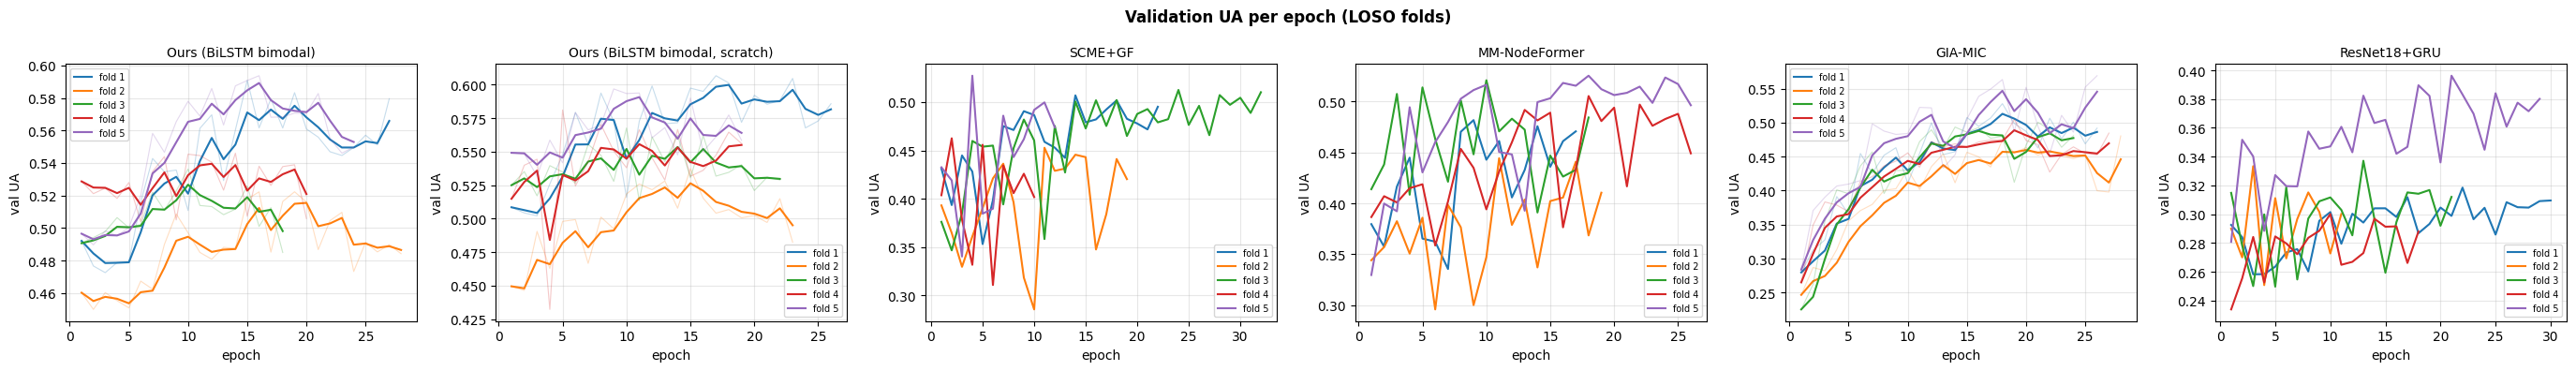

saved -> /Users/kaparya/Desktop/Diploma/trained_models/iemocap_benchmark_4class/logs/training_curves.png


In [52]:
fig, axes = plt.subplots(1, len(MODEL_ZOO), figsize=(4.6 * len(MODEL_ZOO), 4))
for ax, name in zip(np.atleast_1d(axes), MODEL_ZOO):
    mdir = RESULTS_DIR / slug(name)
    for k in range(1, 6):
        fp = mdir / f"fold_{k}.json"
        if not fp.exists():
            continue
        h = json.load(open(fp))["history"]
        eps = [e["epoch"] for e in h]
        raw = [e["val_ua"] for e in h]
        ema = [e.get("val_ua_ema", e["val_ua"]) for e in h]   # back-compat
        # Solid line = EMA-smoothed (the early-stop signal); faint = raw.
        line, = ax.plot(eps, ema, lw=1.5, label=f"fold {k}")
        ax.plot(eps, raw, color=line.get_color(), alpha=0.25, lw=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("epoch"); ax.set_ylabel("val UA"); ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
plt.suptitle("Validation UA per epoch (LOSO folds)", fontweight="bold")
plt.tight_layout()
plt.savefig(LOG_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved ->", LOG_DIR / "training_curves.png")

## 10. Stage 10 — Final benchmark table & confusion matrices

`Model · Params · Modalities · WA · UA · Macro-F1`, mean ± std over the 5 folds.
Saved to `results/benchmark_table.csv`; aggregated per-model confusion matrices
to `results/confusion_matrices.png`.

=== IEMOCAP 4-class · LOSO 5-fold benchmark ===
                         Model Params  Modalities               WA         UA (UAR)         Macro F1
Ours (BiLSTM bimodal, scratch)  5.72M audio+video 0.5311 +- 0.0152 0.5555 +- 0.0315 0.5296 +- 0.0172
         Ours (BiLSTM bimodal)  5.72M audio+video 0.5246 +- 0.0193 0.5457 +- 0.0383 0.5178 +- 0.0276
                       GIA-MIC  0.84M audio+video 0.4545 +- 0.0274 0.4779 +- 0.0338 0.4446 +- 0.0314
                       SCME+GF  0.97M audio+video 0.4127 +- 0.0312 0.4626 +- 0.0294 0.3814 +- 0.0203
                 MM-NodeFormer  1.49M audio+video 0.4145 +- 0.0392 0.4475 +- 0.0173 0.3985 +- 0.0395
                  ResNet18+GRU  0.81M       video 0.3192 +- 0.0480 0.3110 +- 0.0450 0.2782 +- 0.0498

Per-class F1 (mean over folds):
                         Model neutral F1 happy F1 sad F1 angry F1
         Ours (BiLSTM bimodal)      0.508    0.383  0.594    0.587
Ours (BiLSTM bimodal, scratch)      0.512    0.414  0.611    0.582
           

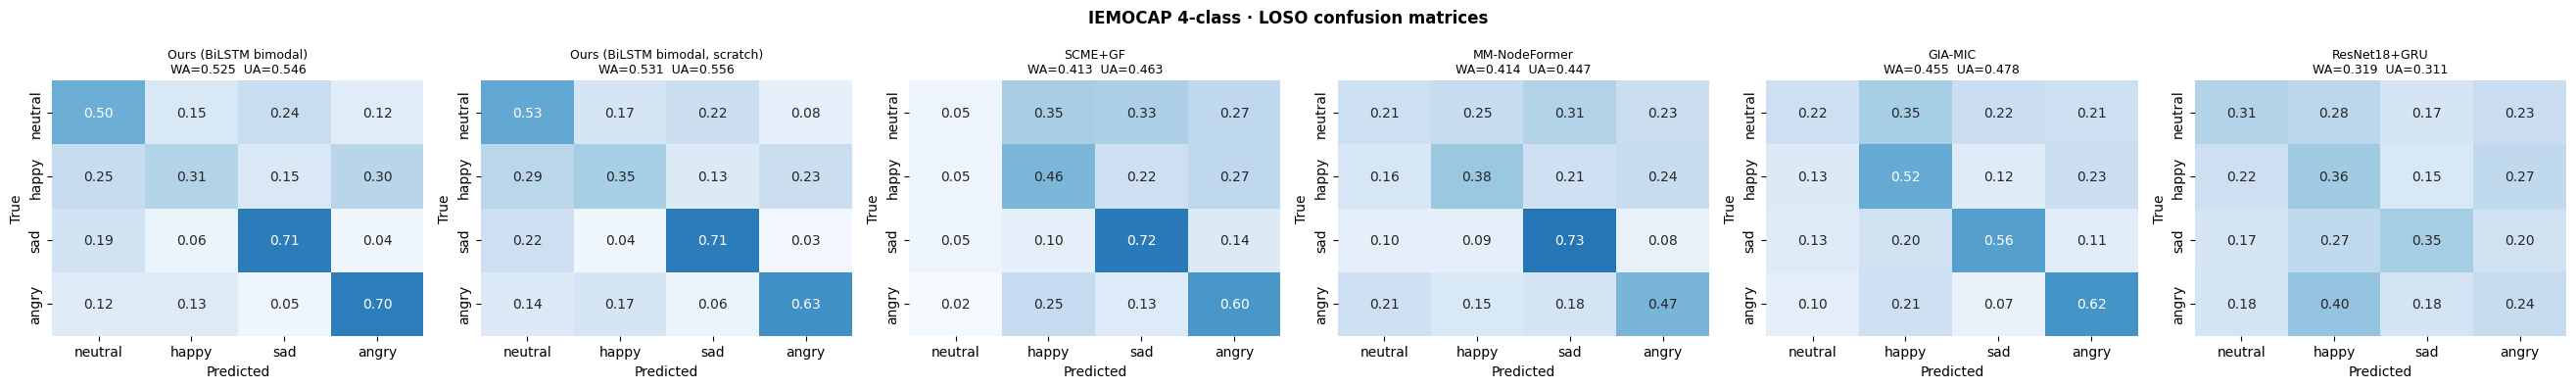


saved -> results/benchmark_table.csv, results/confusion_matrices.png


In [53]:
rows, summaries = [], {}
for name in MODEL_ZOO:
    sp = RESULTS_DIR / slug(name) / "summary.json"
    if not sp.exists():
        continue
    s = json.load(open(sp)); summaries[name] = s
    fmt = lambda v: f"{v[0]:.4f} +- {v[1]:.4f}"
    rows.append({"Model": name,
                 "Params": f"{s['n_params']/1e6:.2f}M",
                 "Modalities": s["modalities"],
                 "WA": fmt(s["wa"]), "UA (UAR)": fmt(s["ua"]),
                 "Macro F1": fmt(s["macro_f1"]),
                 "_ua": s["ua"][0]})
table = (pd.DataFrame(rows).sort_values("_ua", ascending=False)
           .drop(columns="_ua").reset_index(drop=True))
print("=== IEMOCAP 4-class · LOSO 5-fold benchmark ===")
print(table.to_string(index=False))
table.to_csv(RESULTS_DIR / "benchmark_table.csv", index=False)

# --- per-class F1 table ------------------------------------------------
pc_rows = []
for name, s in summaries.items():
    row = {"Model": name}
    row.update({f"{LABELS_4[c]} F1": f"{s['f1_per_class_mean'][c]:.3f}"
                for c in range(N_CLS)})
    pc_rows.append(row)
print("\nPer-class F1 (mean over folds):")
print(pd.DataFrame(pc_rows).to_string(index=False))

# --- aggregated confusion matrices ------------------------------------
n = len(summaries)
fig, axes = plt.subplots(1, n, figsize=(4.4 * n, 4))
for ax, name in zip(np.atleast_1d(axes), summaries):
    mdir = RESULTS_DIR / slug(name)
    cm = np.zeros((N_CLS, N_CLS))
    for k in range(1, 6):
        fp = mdir / f"fold_{k}.json"
        if fp.exists():
            cm += np.array(json.load(open(fp))["confusion"])
    cmn = cm / cm.sum(1, keepdims=True).clip(min=1)
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=LABELS_4, yticklabels=LABELS_4, cbar=False, ax=ax)
    s = summaries[name]
    ax.set_title(f"{name}\nWA={s['wa'][0]:.3f}  UA={s['ua'][0]:.3f}", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("IEMOCAP 4-class · LOSO confusion matrices", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nsaved -> results/benchmark_table.csv, results/confusion_matrices.png")

## 11. Summary plots — UAR / F1 macro / E2E inference time / model size

Aggregated bar charts across the 5 LOSO folds plus two trade-off scatters
(quality vs latency, quality vs model size).

**E2E size** — each model's deployable footprint includes all feature
extractors the production pipeline actually runs (Wav2Vec2 / EmotiEffNet /
ResNet18 / MediaPipe / MelCNN gate) in addition to the trained head.

**E2E latency** — measured from raw wav/avi inputs through the full
pipeline (load → feature extraction → head → logits) on a sample of the
last fold's test set. Cascade timing uses a hard gate threshold (skip
the video pipeline on neutral) — this is the deployable form; soft
log-prior fusion is used only at training for accuracy.

Loading feature extractors for E2E size/latency measurement...


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
I0000 00:00:1779301840.382676 33743912 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1779301840.383708 33743916 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  EmotiEffNet: 15.4 MB | ResNet18: 42.7 MB | Wav2Vec2: 360.0 MB
loaded fine-tuned per-fold gate: gate_iemocap_Session5.pt
timing on 50 utterances from Session5 test set

Ours (BiLSTM bimodal):  size = 37.3 MB  =  head(13.7) + gate(8.1) + emotieffnet(15.4)
  -> 225.6 ms/sample (E2E)
Ours (BiLSTM bimodal, scratch):  size = 37.3 MB  =  head(13.7) + gate(8.1) + emotieffnet(15.4)
  -> 214.6 ms/sample (E2E)
SCME+GF:  size = 379.1 MB  =  head(3.7) + emotieffnet(15.4) + wav2vec2(360.0)
  -> 614.0 ms/sample (E2E)
MM-NodeFormer:  size = 381.1 MB  =  head(5.7) + emotieffnet(15.4) + wav2vec2(360.0)
  -> 613.5 ms/sample (E2E)
GIA-MIC:  size = 378.7 MB  =  head(3.2) + emotieffnet(15.4) + wav2vec2(360.0)
  -> 609.9 ms/sample (E2E)
ResNet18+GRU:  size = 45.7 MB  =  head(3.1) + resnet18(42.7)
  -> 537.8 ms/sample (E2E)

                   name    uar    f1m       ms       mb
0      Ours (BiLSTM bm)  0.546  0.518  225.582   37.267
1  Ours (BiLSTM bm scr)  0.556  0.530  214.635   37.267
2               S

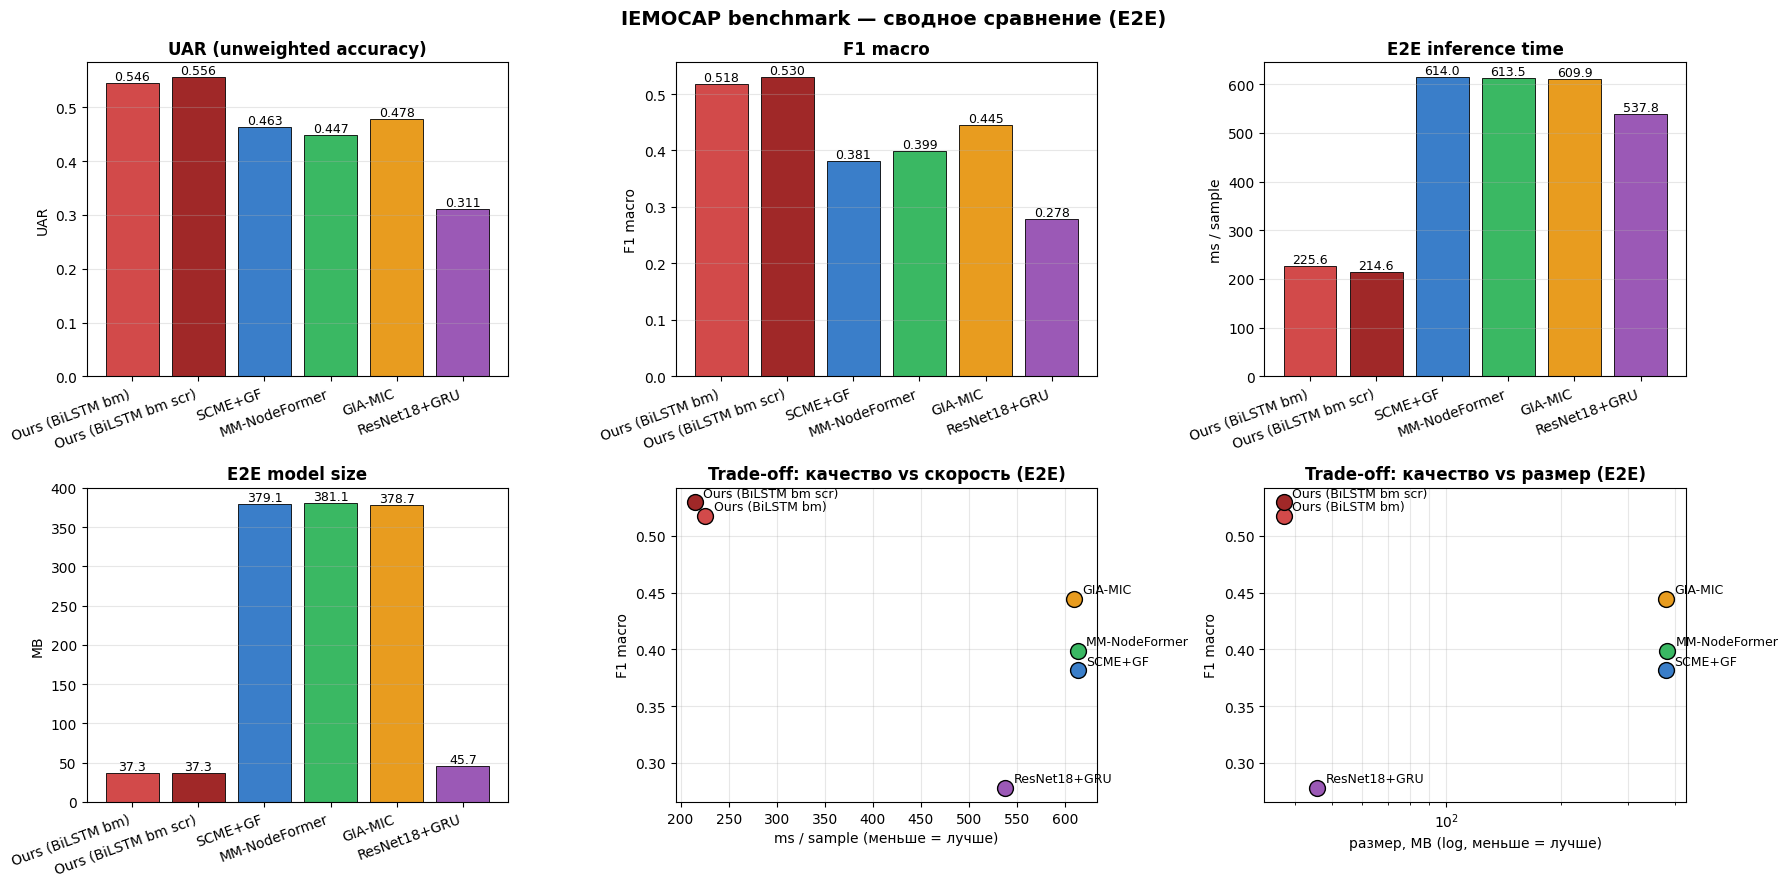

saved /Users/kaparya/Desktop/Diploma/results/benchmark_summary.png


In [54]:
# ----- summary plots: UAR / F1 macro / E2E inference time / model size -----
# Per `notebooks/full_pipeline_iemocap_augmented.ipynb`: a model's deployable
# footprint is NOT just its trained head -- it includes every feature extractor
# the production pipeline must run at inference. Cascade timing also uses a
# HARD threshold on the gate (skip video on neutral) -- this is the deployable
# form; soft log-prior fusion is used only during training for accuracy.

import time as _time
import random
import librosa
import cv2
import torchvision.models as tv_models
import torchvision.transforms as T
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from emotiefflib.facial_analysis import EmotiEffLibRecognizer
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

def size_mb(model):
    """Size in MB including params AND buffers (BatchNorm running stats etc.),
    using each tensor's actual dtype via `element_size()`."""
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2

print("Loading feature extractors for E2E size/latency measurement...")
_eff = EmotiEffLibRecognizer(engine="torch", model_name="enet_b0_8_best_vgaf",
                             device=str(device)).model.to(device).eval()
_res = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
_res.fc = nn.Identity(); _res = _res.to(device).eval()
_w2v_proc = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-960h")
_w2v = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h").to(device).eval()
for _m in (_eff, _res, _w2v):
    for _p in _m.parameters(): _p.requires_grad_(False)
_face_det = mp_vision.FaceDetector.create_from_options(
    mp_vision.FaceDetectorOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(FACE_DETECTOR)),
        min_detection_confidence=0.5))
_imagenet_tf = T.Compose([T.ToTensor(),
                          T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
print(f"  EmotiEffNet: {size_mb(_eff):.1f} MB | ResNet18: {size_mb(_res):.1f} MB | "
      f"Wav2Vec2: {size_mb(_w2v):.1f} MB")

# ----- E2E feature-extraction helpers (lifted from full_pipeline_iemocap_augmented) -----
def _load_wav(p):
    y, _ = librosa.load(p, sr=SR, mono=True); return y

def _logmel(y):
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MEL_LEN:
        lm = np.pad(lm, ((0, 0), (0, MEL_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MEL_LEN]
    return ((lm - MEL_MEAN) / (MEL_STD + 1e-8)).astype(np.float32)

@torch.no_grad()
def _w2v_feat(y, n=N_FRAMES):
    inp = _w2v_proc(y, sampling_rate=SR, return_tensors="pt").input_values.to(device)
    out = _w2v(inp).last_hidden_state[0].cpu().numpy()
    if out.shape[0] >= n:
        idx = np.linspace(0, out.shape[0], n + 1, dtype=int)
        out = np.stack([out[idx[i]:idx[i+1]].mean(0) for i in range(n)])
    else:
        out = np.pad(out, ((0, n - out.shape[0]), (0, 0)))
    return out.astype(np.float32)

def _extract_frames(avi, start, end, n=N_FRAMES):
    cap = cv2.VideoCapture(avi)
    if not cap.isOpened(): return []
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    s = max(0, int(start * fps)); e = min(total - 1, int(end * fps))
    if e <= s: e = min(total - 1, s + 1)
    out = []
    for i in np.linspace(s, e, n, dtype=int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, fr = cap.read()
        if ok: out.append(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    cap.release()
    return out

def _half(frame, side):
    w = frame.shape[1]; mid = w // 2
    return frame[:, :mid] if side == "L" else frame[:, mid:]

def _detect_crop(frame, size=224):
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    r = _face_det.detect(mp_img)
    if r.detections:
        bb = r.detections[0].bounding_box; h, w = frame.shape[:2]
        px, py = int(bb.width * 0.1), int(bb.height * 0.1)
        x1, y1 = max(0, bb.origin_x - px), max(0, bb.origin_y - py)
        x2 = min(w, bb.origin_x + bb.width + px)
        y2 = min(h, bb.origin_y + bb.height + py)
        if x2 > x1 and y2 > y1:
            return cv2.resize(frame[y1:y2, x1:x2], (size, size))
    h, w = frame.shape[:2]; s = min(h, w)
    return cv2.resize(frame[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s], (size, size))

def _mouth_score(crops):
    a = np.stack(crops).astype(np.float32).mean(axis=-1)
    if a.shape[0] < 2: return 0.0
    H, W = a.shape[1], a.shape[2]
    m = a[:, int(H*0.55):int(H*0.92), int(W*0.20):int(W*0.80)]
    b = a[:, int(H*0.15):int(H*0.45), int(W*0.20):int(W*0.80)]
    return float(np.abs(np.diff(m, axis=0)).mean()) - float(np.abs(np.diff(b, axis=0)).mean())

def _speaker_crops(frames):
    cL = [_detect_crop(_half(f, "L")) for f in frames]
    cR = [_detect_crop(_half(f, "R")) for f in frames]
    return cL if _mouth_score(cL) >= _mouth_score(cR) else cR

def _frames_tensor(row):
    fr = _extract_frames(row["video_path"], row["start"], row["end"])
    if not fr:
        crops = [np.zeros((224, 224, 3), np.uint8)] * N_FRAMES
    else:
        while len(fr) < N_FRAMES: fr.append(fr[-1])
        crops = _speaker_crops(fr[:N_FRAMES])
    return torch.stack([_imagenet_tf(c) for c in crops]).to(device)

# ----- per-pipeline timing functions (raw wav/avi -> head logits) -----
N_TIME = 50

@torch.no_grad()
def _time_cascade_video(rows, head, gate):
    """Video-only cascade head. Gate.argmax==neutral -> skip video pipeline."""
    r = rows[0]; y = _load_wav(r["wav_path"])
    mel = torch.from_numpy(_logmel(y))[None, None].to(device); _ = gate(mel)
    ft = _frames_tensor(r); eff = _eff(ft).unsqueeze(0)
    _ = head({"video_eff": eff, "audio_mel": mel})
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = _time.perf_counter()
    for r in rows:
        y = _load_wav(r["wav_path"])
        mel = torch.from_numpy(_logmel(y))[None, None].to(device)
        if gate(mel).argmax(1).item() == 0:
            continue   # hard cascade: skip video on neutral
        ft = _frames_tensor(r); eff = _eff(ft).unsqueeze(0)
        _ = head({"video_eff": eff, "audio_mel": mel})
    if device.type == "cuda": torch.cuda.synchronize()
    return (_time.perf_counter() - t0) * 1000 / len(rows)

@torch.no_grad()
def _time_fusion(rows, head):
    """SCME+GF / MM-NodeFormer / GIA-MIC: always run BOTH audio (Wav2Vec2) and video."""
    r = rows[0]; y = _load_wav(r["wav_path"])
    ft = _frames_tensor(r); eff = _eff(ft).unsqueeze(0)
    aw = torch.from_numpy(_w2v_feat(y)).unsqueeze(0).to(device)
    _ = head({"video_eff": eff, "audio_w2v": aw})
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = _time.perf_counter()
    for r in rows:
        y = _load_wav(r["wav_path"])
        ft = _frames_tensor(r); eff = _eff(ft).unsqueeze(0)
        aw = torch.from_numpy(_w2v_feat(y)).unsqueeze(0).to(device)
        _ = head({"video_eff": eff, "audio_w2v": aw})
    if device.type == "cuda": torch.cuda.synchronize()
    return (_time.perf_counter() - t0) * 1000 / len(rows)

@torch.no_grad()
def _time_resnet(rows, head):
    """ResNet18+GRU: video only, no audio."""
    r = rows[0]
    ft = _frames_tensor(r); res = _res(ft).unsqueeze(0)
    _ = head({"video_res": res})
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = _time.perf_counter()
    for r in rows:
        ft = _frames_tensor(r); res = _res(ft).unsqueeze(0)
        _ = head({"video_res": res})
    if device.type == "cuda": torch.cuda.synchronize()
    return (_time.perf_counter() - t0) * 1000 / len(rows)

def _components_for(name, head, fold_gate):
    """Return list of (module, label) whose .parameters() count toward E2E size."""
    spec = MODEL_ZOO[name]
    lst = [(head, "head")]
    if spec["cascade"]:
        lst.append((fold_gate, "gate"))
    if name == "ResNet18+GRU":
        lst.append((_res, "resnet18"))
    else:
        lst.append((_eff, "emotieffnet"))
    # SCME+GF / MM-NodeFormer consume Wav2Vec2 features at inference; our
    # bimodal head reuses the MelCNN gate's backbone, so it does NOT need
    # Wav2Vec2 -- the gate is already counted via `lst.append((fold_gate, "gate"))`.
    if name in ("SCME+GF", "MM-NodeFormer", "GIA-MIC"):
        lst.append((_w2v, "wav2vec2"))
    return lst

def _short_name(name):
    # Order matters: more-specific names FIRST so the substring "(BiLSTM bimodal)"
    # doesn't get mangled into "(BiLSTM bm)" before "scratch" suffix is added.
    return (name.replace("Ours (MelCNN->BiLSTM)", "Ours (BiLSTM)")
                .replace("Ours (BiLSTM bimodal, scratch)", "Ours (BiLSTM bm scr)")
                .replace("Ours (BiLSTM bimodal)", "Ours (BiLSTM bm)")
                .replace("Ours (BiLSTM, scratch)", "Ours (BiLSTM scratch)"))

# Load per-fold gate (last fold = Session5) for the cascade timing.
last_sess = SESSIONS[-1]
gate_ckpt = CKPT_DIR / f"gate_iemocap_{last_sess}.pt"
if gate_ckpt.exists():
    fold_gate = MelCNN(N_MELS, MEL_LEN)
    fold_gate.load_state_dict(torch.load(gate_ckpt, map_location="cpu"))
    fold_gate = fold_gate.to(device).eval()
    for _p in fold_gate.parameters(): _p.requires_grad_(False)
    print(f"loaded fine-tuned per-fold gate: {gate_ckpt.name}")
else:
    fold_gate = GATE
    print("WARN: per-fold gate not found, using pretrained global GATE")

# Sample N_TIME utterances from the last fold's test set.
te_last = meta[meta.session == last_sess].reset_index(drop=True)
rng = random.Random(SEED)
time_rows = [te_last.iloc[i].to_dict() for i in
             rng.sample(range(len(te_last)), min(N_TIME, len(te_last)))]
print(f"timing on {len(time_rows)} utterances from {last_sess} test set\n")

# Aggregate accuracy from fold JSONs; load last-fold checkpoint for size+timing.
plot_rows = []
for name, spec in MODEL_ZOO.items():
    mdir = RESULTS_DIR / slug(name)
    folds = sorted(mdir.glob("fold_*.json"))
    if not folds:
        print(f"skip {name}: no fold JSONs"); continue
    uars, f1ms = [], []
    for fj in folds:
        r = json.load(open(fj))
        yt, pr = np.array(r["y_true"]), np.array(r["y_pred"])
        uars.append(balanced_accuracy_score(yt, pr))
        f1ms.append(f1_score(yt, pr, average="macro", zero_division=0))

    ckpt = CKPT_DIR / f"{slug(name)}_{last_sess}.pt"
    ms, mb = float("nan"), float("nan")
    if ckpt.exists():
        try:
            head = spec["builder"]().to(device).eval()
            head.load_state_dict(torch.load(ckpt, map_location=device))
            for _p in head.parameters(): _p.requires_grad_(False)
            comps = _components_for(name, head, fold_gate)
            mb = sum(size_mb(m) for m, _ in comps)
            comp_str = " + ".join(f"{lbl}({size_mb(m):.1f})" for m, lbl in comps)
            print(f"{name}:  size = {mb:.1f} MB  =  {comp_str}")
            if spec["cascade"]:
                # Both unimodal and bimodal cascade heads consume audio_mel
                # through the (shared) MelCNN backbone -- same E2E timing path.
                ms = _time_cascade_video(time_rows, head, fold_gate)
            elif name == "ResNet18+GRU":
                ms = _time_resnet(time_rows, head)
            else:
                ms = _time_fusion(time_rows, head)
            print(f"  -> {ms:.1f} ms/sample (E2E)")
            del head; gc.collect()
            if device.type == "cuda": torch.cuda.empty_cache()
        except Exception as e:
            print(f"  E2E measurement failed for {name}: {e}")
    else:
        print(f"  {name}: no checkpoint, skipping size/timing")
    plot_rows.append(dict(name=_short_name(name),
                          uar=float(np.mean(uars)),
                          f1m=float(np.mean(f1ms)),
                          ms=ms, mb=mb))

df_p = pd.DataFrame(plot_rows)
print()
print(df_p.round(3))

# ----- plot -----
colors = ["#d24a4a", "#a02828", "#3a7ec9", "#3ab863", "#e89c1f", "#9b59b6"][:len(df_p)]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("IEMOCAP benchmark — сводное сравнение (E2E)",
             fontsize=14, fontweight="bold")

def _bar(ax, vals, ylabel, title, fmt="{:.3f}"):
    bars = ax.bar(df_p["name"], vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
    for b, v in zip(bars, vals):
        if np.isnan(v): continue
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                fmt.format(v), ha="center", va="bottom", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

_bar(axes[0, 0], df_p["uar"], "UAR",           "UAR (unweighted accuracy)")
_bar(axes[0, 1], df_p["f1m"], "F1 macro",      "F1 macro")
_bar(axes[0, 2], df_p["ms"],  "ms / sample",   "E2E inference time", fmt="{:.1f}")
_bar(axes[1, 0], df_p["mb"],  "MB",            "E2E model size",     fmt="{:.1f}")

def _scatter(ax, xcol, xlabel, title, logx=False):
    for i, r in df_p.iterrows():
        if np.isnan(r[xcol]) or np.isnan(r["f1m"]): continue
        ax.scatter(r[xcol], r["f1m"], color=colors[i], s=130,
                   edgecolor="black", zorder=3)
        ax.annotate(r["name"], (r[xcol], r["f1m"]), xytext=(6, 4),
                    textcoords="offset points", fontsize=9)
    if logx: ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel("F1 macro")
    ax.set_title(title, fontweight="bold"); ax.grid(alpha=0.3, which="both")

_scatter(axes[1, 1], "ms", "ms / sample (меньше = лучше)",
         "Trade-off: качество vs скорость (E2E)")
_scatter(axes[1, 2], "mb", "размер, MB (log, меньше = лучше)",
         "Trade-off: качество vs размер (E2E)", logx=True)

plt.tight_layout()
out_png = RESULTS_DIR / "benchmark_summary.png"
fig.savefig(out_png, dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {out_png}")


## Reproducibility log & README

Records the git hash, config, device and package versions to
`trained_models/iemocap_benchmark_4class/run_meta.json`, and writes
`results/README.md` with full reproduction instructions.

In [55]:
run_meta = dict(
    git_hash=git_hash(), seed=SEED, device=str(device),
    timestamp=time.strftime("%Y-%m-%d %H:%M:%S"),
    n_utterances=int(len(meta)), classes=LABELS_4,
    sessions=SESSIONS, loso_val_for_test=LOSO_VAL_FOR_TEST,
    train_cfg=TRAIN_CFG,
    versions=dict(python=platform.python_version(),
                  torch=torch.__version__, numpy=np.__version__,
                  pandas=pd.__version__),
)
json.dump(run_meta, open(OUT_DIR / "run_meta.json", "w"), indent=2)

readme = f"""# IEMOCAP MER Benchmark — 4-class, LOSO 5-fold

Audio + facial-expression emotion recognition benchmark on IEMOCAP, produced by
`notebooks/iemocap_benchmark_4class.ipynb`.

## Protocol
- **Classes:** neutral, happy (incl. excited), sad, angry.
- **Split:** Leave-One-Session-Out 5-fold; metrics are mean +- std over folds.
- **Metrics:** WA, UA/UAR (main), Macro-F1, per-class F1, confusion matrix.
- **Face selection:** gender-letter heuristic (speaker letter in the utterance
  id picks the half-frame); MediaPipe BlazeFace crop.

## Reproduce
1. `source venv/bin/activate && jupyter notebook`
2. Open `notebooks/iemocap_benchmark_4class.ipynb`, Run All. The first run
   builds the feature cache `datasets/iemocap_features_cache/` if missing
   (slow, one-time); later runs reuse it.
3. Outputs:
   - `metadata/iemocap_4class.csv` — dataset index
   - `results/<model>/fold_k.json`, `summary.json` — per-fold & aggregated metrics
   - `results/benchmark_table.csv` — final comparison table
   - `results/confusion_matrices.png`, `logs/training_curves.png`
   - `trained_models/iemocap_benchmark_4class/checkpoints/` — per-fold weights
   - `run_meta.json` — git hash, config, versions

Set `BENCH_QUICK=1` in the environment for a fast 2-epoch smoke run.
Reproducibility: fixed seeds, deterministic algorithms, git hash logged.
"""
open(RESULTS_DIR / "README.md", "w").write(readme)
print("saved -> run_meta.json, results/README.md")
print(json.dumps(run_meta, indent=2, default=str))

saved -> run_meta.json, results/README.md
{
  "git_hash": "95bc39e585894e5ee6339c2b750de8478c5a2c42",
  "seed": 42,
  "device": "mps",
  "timestamp": "2026-05-20 21:33:06",
  "n_utterances": 5531,
  "classes": [
    "neutral",
    "happy",
    "sad",
    "angry"
  ],
  "sessions": [
    "Session1",
    "Session2",
    "Session3",
    "Session4",
    "Session5"
  ],
  "loso_val_for_test": {
    "Session1": "Session2",
    "Session2": "Session3",
    "Session3": "Session4",
    "Session4": "Session5",
    "Session5": "Session1"
  },
  "train_cfg": {
    "epochs": 40,
    "patience": 8,
    "batch_size": 64,
    "lr": 0.001,
    "lr_finetune": 0.0003,
    "weight_decay": 0.0001,
    "label_smoothing": 0.1,
    "grad_clip": 1.0,
    "accum_steps": 1,
    "num_workers": 0,
    "augment": false,
    "aug_noise": 0.05
  },
  "versions": {
    "python": "3.12.7",
    "torch": "2.10.0",
    "numpy": "2.3.0",
    "pandas": "3.0.0"
  }
}
